# Customer Segmentation Analysis using K-Means Clustering
## Objective
The objective of this project is to segment customers based on their purchasing behavior using the K-Means clustering algorithm.
Customer segmentation helps businesses identify different groups of customers and create targeted marketing strategies that improve customer retention and increase revenue.
## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

In [124]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
pd.set_option('display.max_columns', None)

In [125]:
#Load dataset
df = pd.read_csv(r"C:\Users\rojam\OneDrive\Desktop\projects\Task-3\Online Retail.csv", encoding='ISO-8859-1')

In [126]:
#display dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [127]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [128]:
#Dataset Inspection
df.shape

(541909, 8)

In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [130]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [131]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [132]:
df.dtypes

InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

The dataset was inspected to understand its structure before preprocessing.
The following checks were performed:
- Dataset dimensions
- Column names
- Data types
- Summary statistics
These checks help identify potential data quality issues before analysis.

In [133]:
#Missing Values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [134]:
df.duplicated().sum()

np.int64(5268)

In [135]:
#Remove Missing Customer IDs
df = df.dropna(subset=['CustomerID'])

In [136]:
#Remove duplicate rows
df = df.drop_duplicates()

In [137]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [138]:
#Create Total Amount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

In [139]:
#Descriptive Statistics
df['TotalAmount'].mean()

np.float64(20.613637872132745)

In [140]:
df['Quantity'].mean()

np.float64(12.183272576966365)

In [141]:
df['UnitPrice'].mean()

np.float64(3.4740636398043847)

# Descriptive Statistics
Basic statistics were calculated to understand purchasing behavior.
The analysis includes:
- Average purchase value
- Average quantity purchased
- Average unit price
These metrics provide a high-level overview of customer transactions.

# Feature Engineering - RFM Analysis
Customer segmentation is based on three important behavioral features:
- Recency (R):Number of days since the customer's last purchase.
- Frequency (F):Number of purchases made by the customer.
- Monetary (M):Total amount spent by the customer.
These features help identify valuable customers and create targeted marketing strategies.

In [142]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [143]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

In [144]:
#Create RFM Table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

In [145]:
#Rename Columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


The RFM table summarizes customer purchasing behavior:
- Recency: Lower values indicate more recent purchases.
- Frequency:Higher values indicate more frequent purchases.
- Monetary:Higher values indicate greater spending.

In [146]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,92.047118,5.075480,1893.531433
std,100.765435,9.338754,8218.696204
min,1.000000,1.000000,-4287.630000
25%,17.000000,1.000000,291.795000
50%,50.000000,3.000000,644.070000
75%,143.000000,5.000000,1608.335000
max,374.000000,248.000000,279489.020000


In [147]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

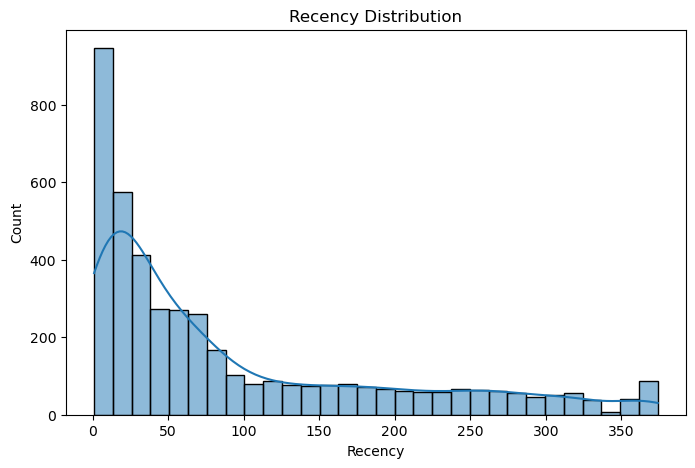

In [148]:
#Distribution of RFM Features
plt.figure(figsize=(8,5))
sns.histplot(rfm['Recency'], bins=30, kde=True)
plt.title("Recency Distribution")
plt.savefig("Recency Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

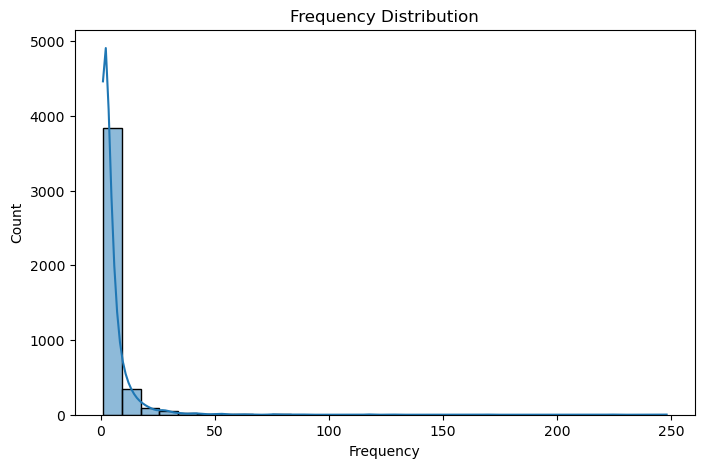

In [149]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Frequency'], bins=30, kde=True)
plt.title("Frequency Distribution")
plt.savefig("Frequency Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

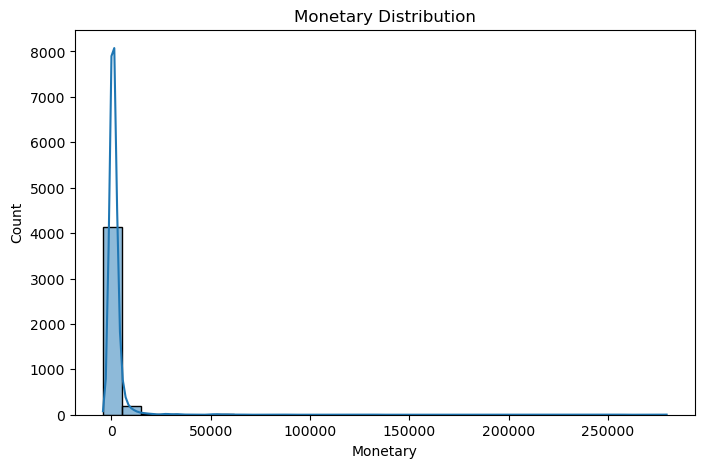

In [150]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['Monetary'], bins=30, kde=True)
plt.title("Monetary Distribution")
plt.savefig("Monetary Distribution.png",dpi=300,bbox_inches="tight")
plt.show()

The RFM features show varying customer purchasing behaviors.
- Customers with low Recency have purchased recently.
- Customers with high Frequency purchase more often.
- Customers with high Monetary values contribute the most revenue.
These features will be used as inputs for the K-Means clustering algorithm.

# Data Standardization 
The RFM features have different scales.
- Recency is measured in days.
- Frequency is measured as the number of purchases.
- Monetary is measured in currency.
Since K-Means uses Euclidean distance, features with larger values can dominate the clustering process. Therefore, the RFM features are standardized using StandardScaler.

In [151]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
rfm_features.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [152]:
#Standardize Using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

In [153]:
#Convert back to dataframe
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)
rfm_scaled.head()

,Recency,Frequency,Monetary
0,2.322023,-0.329362,-0.230420
1,-0.893733,0.206102,0.294055
2,-0.169196,-0.115176,-0.011717
3,-0.725005,-0.436455,-0.016547
4,2.163220,-0.436455,-0.189727


- All RFM features have been standardized with a mean close to 0 and a standard deviation close to 1.
- This ensures that each feature contributes equally during clustering.

# Elbow Method

# Finding the Optimal Number of Clusters
The Elbow Method is used to determine the optimal number of clusters (K).
The Within-Cluster Sum of Squares (WCSS) is calculated for different values of K.
The optimal K is identified where the decrease in WCSS begins to level off, forming an "elbow" in the graph.

In [154]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

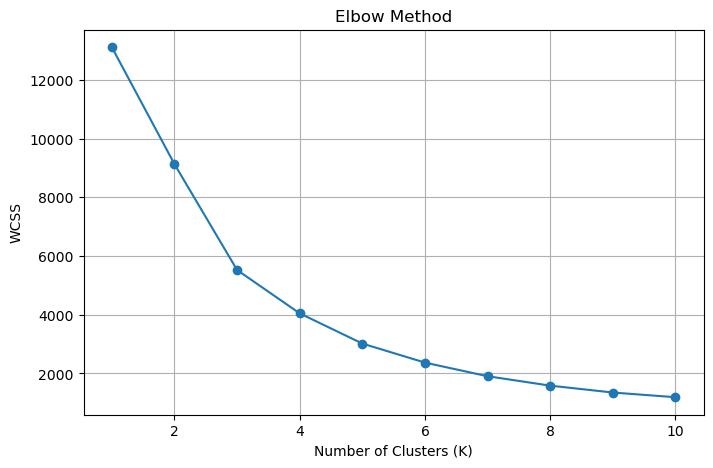

In [155]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.savefig("Elbow Method.png",dpi=300,bbox_inches="tight")
plt.show()

- The Elbow Curve shows that the rate of decrease in WCSS slows after a certain point.
- The point where the curve bends is considered the optimal number of clusters for the K-Means algorithm.

In [156]:
optimal_k = 4

#Applying K-Means Clustering
- After determining the optimal number of clusters using the Elbow Method, the K-Means algorithm is applied to segment customers based on their RFM (Recency, Frequency, Monetary) features.
- Each customer is assigned to one cluster representing similar purchasing behavior.

In [157]:
kmeans = KMeans(
    n_clusters=4,      # Replace 4 with your optimal K if different
    random_state=42,
    n_init=10
)
kmeans.fit(rfm_scaled)

,n_clusters,4
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [158]:
rfm['Cluster'] = kmeans.labels_

In [159]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [160]:
rfm['Cluster'].value_counts().sort_index()

Cluster
0    3169
1    1087
2       6
3     110
Name: count, dtype: int64

In [161]:
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['Recency', 'Frequency', 'Monetary']
)
centers

,Recency,Frequency,Monetary
0,41.606500,4.802461,1472.653251
1,247.951242,1.805888,451.802991
2,7.666667,89.000000,182108.075000
3,9.181818,40.672727,18435.663364


- The K-Means model successfully segmented customers into distinct groups based on their purchasing behavior.
- Each customer has been assigned to a cluster, which will be analyzed further to understand customer characteristics and recommend suitable marketing strategies.

# Cluster Visualization
After applying the K-Means algorithm, the customer segments are visualized to understand the relationship between different RFM features.
Scatter plots help identify how customers are grouped based on their purchasing behavior.

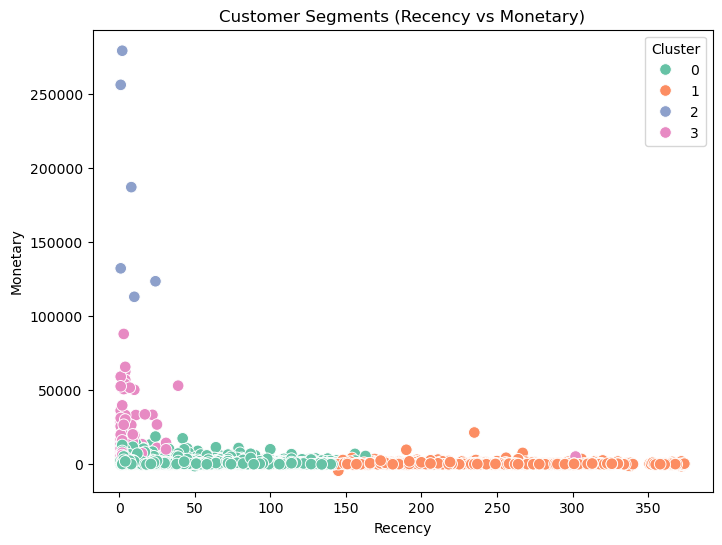

In [162]:
#Scatter Plot (Recency vs Monetary)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='Set2',
    s=70
)
plt.title("Customer Segments (Recency vs Monetary)")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.savefig("Customer Segments(Recency vs Monetary).png",dpi=300,bbox_inches="tight")
plt.show()

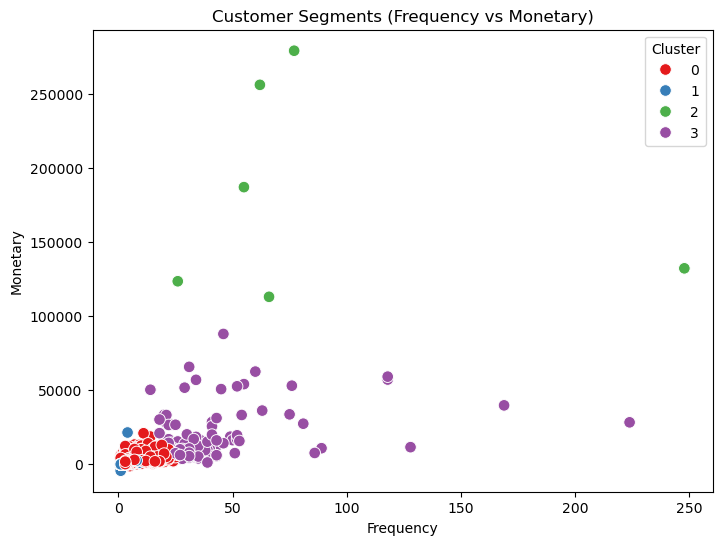

In [163]:
#Scatter Plot (Frequency vs Monetary)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set1',
    s=70
)
plt.title("Customer Segments (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.savefig("Customer Segments (Frequency vs Monetary).png",dpi=300,bbox_inches="tight")
plt.show()

- The scatter plots show that customers have been grouped into distinct clusters based on their purchasing behavior.
- Customers with higher spending and purchase frequency are separated from those with lower engagement, making it easier to identify valuable customer segments.

In [164]:
#Cluster Profiling
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,41.61,4.80,1472.65
1,247.95,1.81,451.80
2,7.67,89.00,182108.08
3,9.18,40.67,18435.66


The average RFM values for each cluster provide insights into customer purchasing behavior.
- Low Recency = Recently active customers
- High Frequency = Loyal customers
- High Monetary = High-value customers

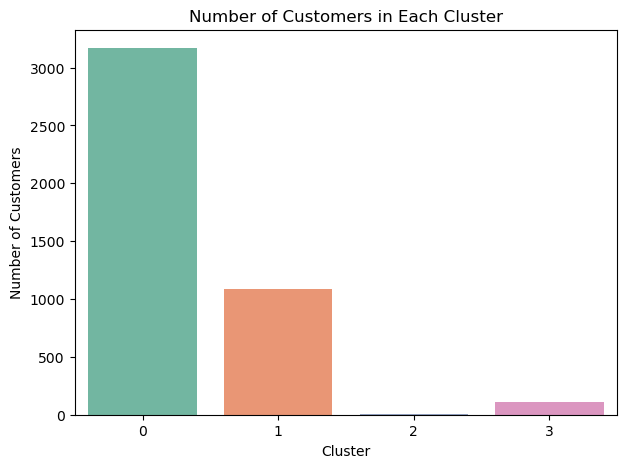

In [165]:
plt.figure(figsize=(7,5))
sns.countplot(x='Cluster',hue='Cluster',data=rfm,palette='Set2',legend=False)
plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.savefig("Number of Customers in Each Cluster.png",dpi=300,bbox_inches="tight")
plt.show()

# Marketing Recommendations
### Cluster 0 – High Value Customers
- Offer exclusive rewards and loyalty programs.
- Provide early access to new products.
- Encourage referrals through premium benefits.
### Cluster 1 – At Risk Customers
- Send personalized discount offers.
- Launch win-back email campaigns.
- Recommend products based on previous purchases.
### Cluster 2 – Regular Customers
- Offer bundle deals and cross-selling opportunities.
- Encourage more frequent purchases with reward points.
- Share personalized product recommendations.
### Cluster 3 – New or Low-Spending Customers
- Welcome offers and onboarding discounts.
- Educational emails introducing popular products.
- Limited-time promotions to encourage repeat purchases.

# Conclusion
This project successfully segmented customers using the K-Means clustering algorithm based on RFM (Recency, Frequency, Monetary) analysis.
## Key Achievements
- Loaded and explored the Online Retail dataset.
- Cleaned and prepared the data.
- Engineered RFM features.
- Standardized the data using StandardScaler.
- Determined the optimal number of clusters using the Elbow Method.
- Applied the K-Means clustering algorithm.
- Visualized customer segments.
- Profiled each customer cluster.
- Recommended targeted marketing strategies.
## Business Impact
Customer segmentation enables organizations to understand customer behavior, improve marketing campaigns, increase customer retention, and maximize revenue through personalized strategies.